# **Project Machine Learning Prediksi Performa Akademik Mahasiswa Berdasarkan Faktor Akademik dan Non-Akademik (Regresi)**

## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import pickle

## **Data Understanding**

In [2]:
df = pd.read_csv('/content/Student_performance_data _ (3).csv')
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [4]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


## **DATA PREPROCESSING**

In [5]:
print(df.dtypes)

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object


In [6]:
(df.isnull().sum())

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop(columns=['StudentID', 'Age', 'Volunteering', 'Gender', 'Ethnicity', 'ParentalEducation', 'Sports'], errors='ignore')

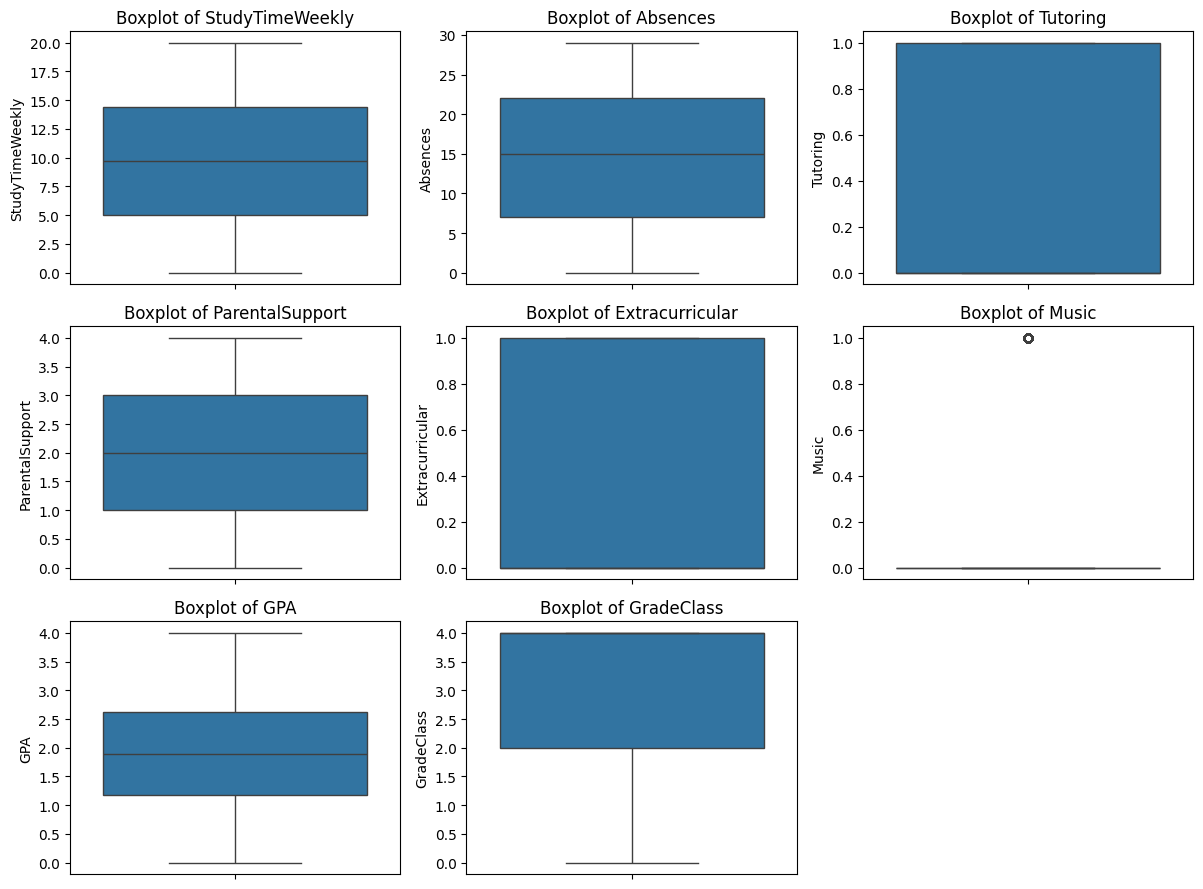

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the number of rows and columns for the subplot grid dynamically
num_plots = len(numerical_cols)
num_cols_subplot = min(4, math.ceil(math.sqrt(num_plots))) # Aim for a max of 4 columns to keep plots readable
num_rows_subplot = math.ceil(num_plots / num_cols_subplot)

plt.figure(figsize=(num_cols_subplot * 4, num_rows_subplot * 3))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows_subplot, num_cols_subplot, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## **Exploratory Data Analysis (EDA)**

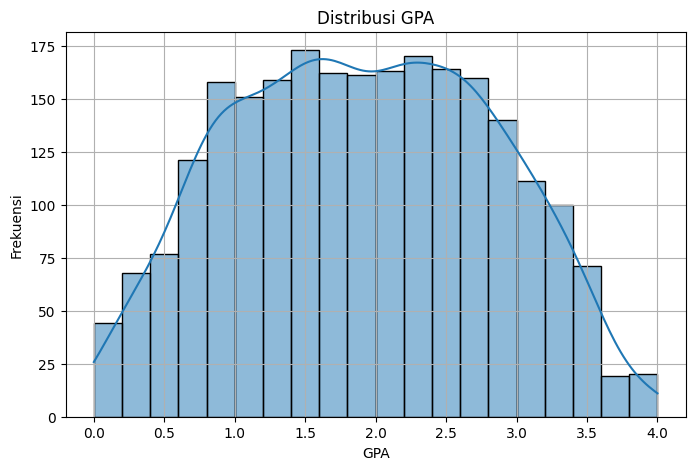

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['GPA'], kde=True, bins=20)

plt.title('Distribusi GPA')
plt.xlabel('GPA')
plt.ylabel('Frekuensi')
plt.grid(True)

plt.show()

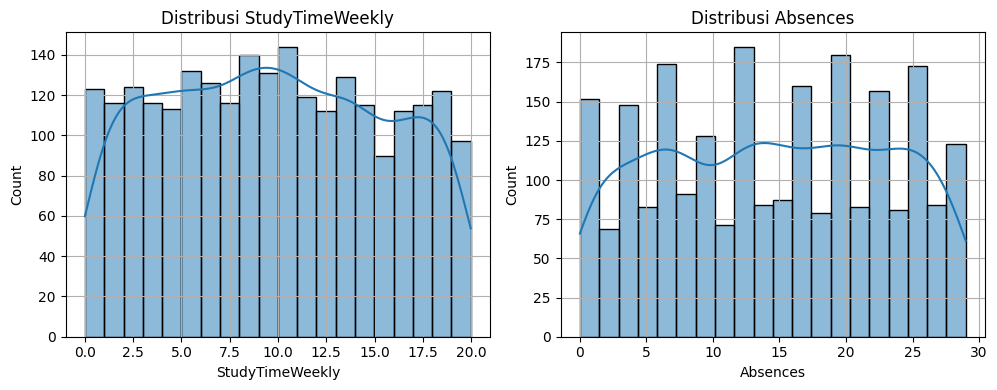

In [11]:
cols = ['StudyTimeWeekly', 'Absences']

plt.figure(figsize=(15,4))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)

    sns.histplot(df[col], kde=True, bins=20)

    plt.title(f'Distribusi {col}')
    plt.grid(True)

plt.tight_layout()
plt.show()

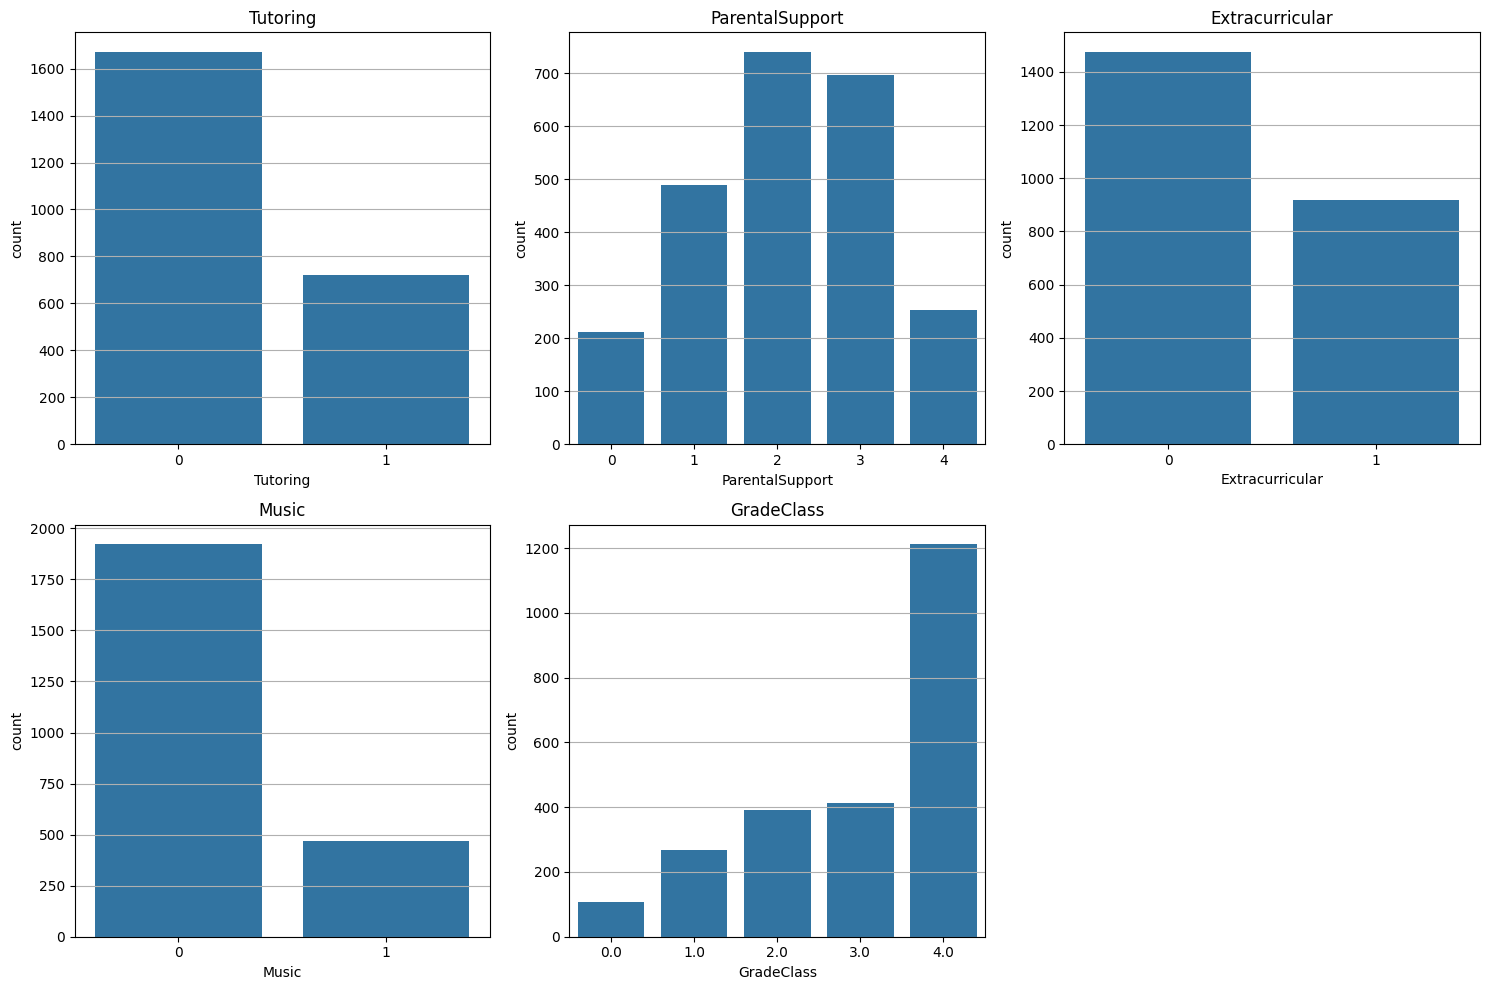

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# pilih kolom kategorikal (biasanya nilai kecil / kategori)
categorical_cols = [
    'Tutoring', 'ParentalSupport', 'Extracurricular',
    'Music', 'GradeClass'
]

# jumlah kolom
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.countplot(x=col, data=df)

    plt.title(col)
    plt.grid(axis='y')

plt.tight_layout()
plt.show()

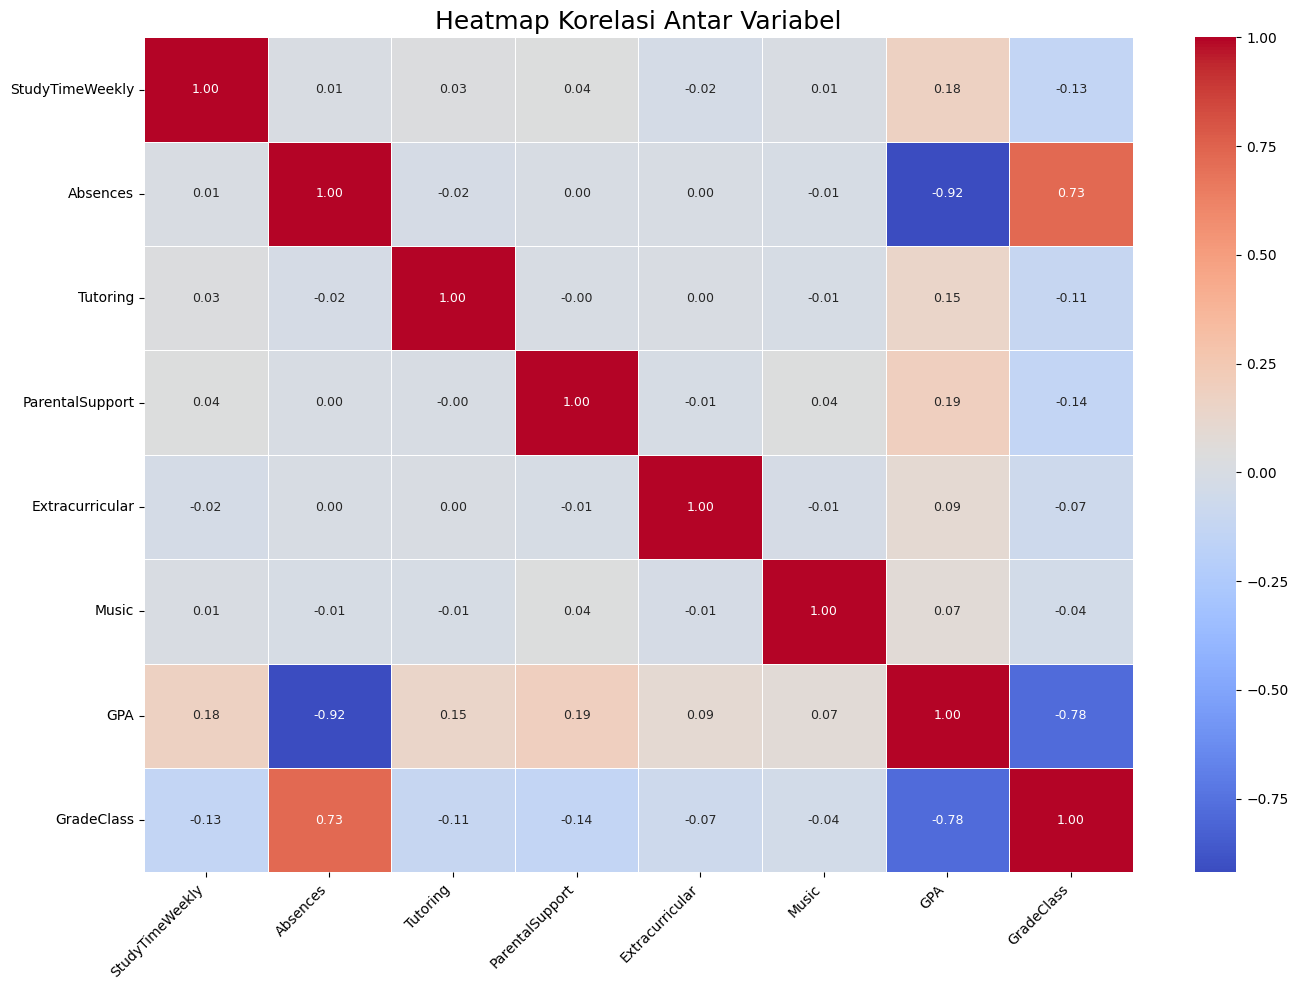

In [13]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 9}
)

plt.title('Heatmap Korelasi Antar Variabel', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
corr_target = df.corr()['GPA'].sort_values(ascending=False)
print(corr_target)

GPA                1.000000
ParentalSupport    0.190774
StudyTimeWeekly    0.179275
Tutoring           0.145119
Extracurricular    0.094078
Music              0.073318
GradeClass        -0.782835
Absences          -0.919314
Name: GPA, dtype: float64


## **Data Splitting**

In [15]:
X = df.drop('GPA', axis=1)
y = df['GPA']

In [16]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

In [17]:
splits = {
    '70:30': (X_train_70, X_test_70, y_train_70, y_test_70),
    '80:20': (X_train_80, X_test_80, y_train_80, y_test_80),
    '90:10': (X_train_90, X_test_90, y_train_90, y_test_90)
}

## **Model Building**

In [18]:
results = []

In [19]:
# ==========================================
# Linear Regression
# ==========================================

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    lr_pipeline.fit(X_train, y_train)

    y_pred_lr = lr_pipeline.predict(X_test)

    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mse_lr)
    r2_lr = r2_score(y_test, y_pred_lr)

    results.append([
        split_name,
        'Linear Regression',
        mae_lr,
        mse_lr,
        rmse_lr,
        r2_lr
    ])

In [20]:
# ==========================================
# Random Forest
# ==========================================

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    rf_model = RandomForestRegressor(random_state=42)

    rf_params = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    grid_rf = GridSearchCV(
        estimator=rf_model,
        param_grid=rf_params,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid_rf.fit(X_train, y_train)

    best_rf = grid_rf.best_estimator_

    y_pred_rf = best_rf.predict(X_test)

    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mse_rf)
    r2_rf = r2_score(y_test, y_pred_rf)

    results.append([
        split_name,
        'Random Forest',
        mae_rf,
        mse_rf,
        rmse_rf,
        r2_rf
    ])

In [21]:
# ==========================================
# Xgboost
# ==========================================

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    xgb_model = XGBRegressor(random_state=42)

    xgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }

    grid_xgb = GridSearchCV(
        estimator=xgb_model,
        param_grid=xgb_params,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid_xgb.fit(X_train, y_train)

    best_xgb = grid_xgb.best_estimator_

    y_pred_xgb = best_xgb.predict(X_test)

    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mse_xgb)
    r2_xgb = r2_score(y_test, y_pred_xgb)

    results.append([
        split_name,
        'XGBoost',
        mae_xgb,
        mse_xgb,
        rmse_xgb,
        r2_xgb
    ])

## Model Comparison

In [22]:
results_df = pd.DataFrame(results, columns=[
    'Split',
    'Model',
    'MAE',
    'MSE',
    'RMSE',
    'R2 Score'
])

print(results_df.to_string(index=False))

Split             Model      MAE      MSE     RMSE  R2 Score
70:30 Linear Regression 0.169907 0.044995 0.212119  0.946564
80:20 Linear Regression 0.165985 0.045020 0.212178  0.945558
90:10 Linear Regression 0.171127 0.048999 0.221357  0.943901
70:30     Random Forest 0.173576 0.053444 0.231180  0.936530
80:20     Random Forest 0.170817 0.051785 0.227563  0.937377
90:10     Random Forest 0.177228 0.062007 0.249012  0.929008
70:30           XGBoost 0.155716 0.040707 0.201760  0.951656
80:20           XGBoost 0.160400 0.044030 0.209833  0.946755
90:10           XGBoost 0.165971 0.050008 0.223625  0.942746


Linear Regression

In [23]:
print(results_df[results_df['Model'] == 'Linear Regression'].to_string(index=False))

Split             Model      MAE      MSE     RMSE  R2 Score
70:30 Linear Regression 0.169907 0.044995 0.212119  0.946564
80:20 Linear Regression 0.165985 0.045020 0.212178  0.945558
90:10 Linear Regression 0.171127 0.048999 0.221357  0.943901


Random Forest

In [24]:
print(results_df[results_df['Model'] == 'Random Forest'].to_string(index=False))

Split         Model      MAE      MSE     RMSE  R2 Score
70:30 Random Forest 0.173576 0.053444 0.231180  0.936530
80:20 Random Forest 0.170817 0.051785 0.227563  0.937377
90:10 Random Forest 0.177228 0.062007 0.249012  0.929008


Xgboost

In [25]:
print(results_df[results_df['Model'] == 'XGBoost'].to_string(index=False))

Split   Model      MAE      MSE     RMSE  R2 Score
70:30 XGBoost 0.155716 0.040707 0.201760  0.951656
80:20 XGBoost 0.160400 0.044030 0.209833  0.946755
90:10 XGBoost 0.165971 0.050008 0.223625  0.942746


In [26]:
results_df = results_df.sort_values(by='R2 Score', ascending=False)

print(results_df)

   Split              Model       MAE       MSE      RMSE  R2 Score
6  70:30            XGBoost  0.155716  0.040707  0.201760  0.951656
7  80:20            XGBoost  0.160400  0.044030  0.209833  0.946755
0  70:30  Linear Regression  0.169907  0.044995  0.212119  0.946564
1  80:20  Linear Regression  0.165985  0.045020  0.212178  0.945558
2  90:10  Linear Regression  0.171127  0.048999  0.221357  0.943901
8  90:10            XGBoost  0.165971  0.050008  0.223625  0.942746
4  80:20      Random Forest  0.170817  0.051785  0.227563  0.937377
3  70:30      Random Forest  0.173576  0.053444  0.231180  0.936530
5  90:10      Random Forest  0.177228  0.062007  0.249012  0.929008


In [27]:
best_model = results_df.iloc[0]

print(best_model)

Split          70:30
Model        XGBoost
MAE         0.155716
MSE         0.040707
RMSE         0.20176
R2 Score    0.951656
Name: 6, dtype: object


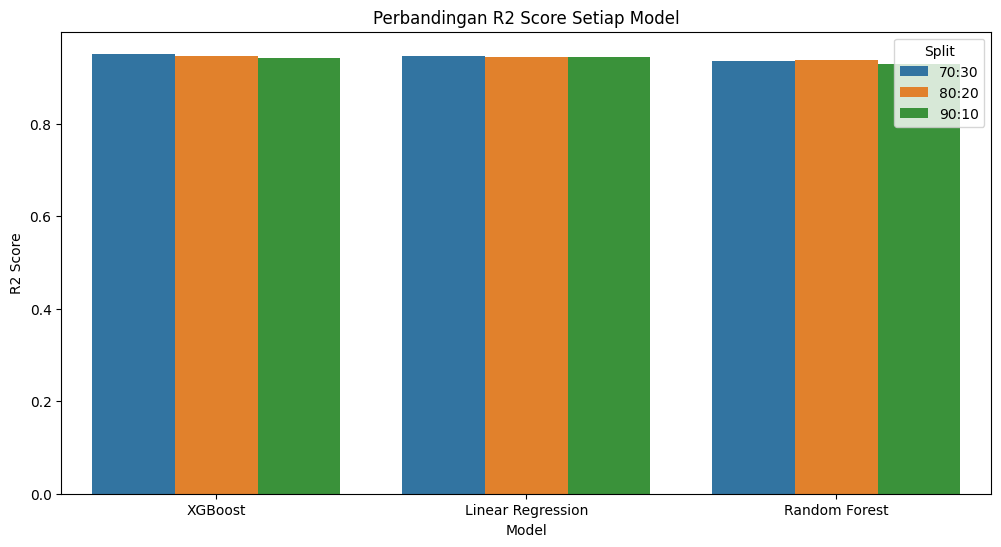

In [28]:
plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x='Model', y='R2 Score', hue='Split')
plt.title('Perbandingan R2 Score Setiap Model')
plt.show()

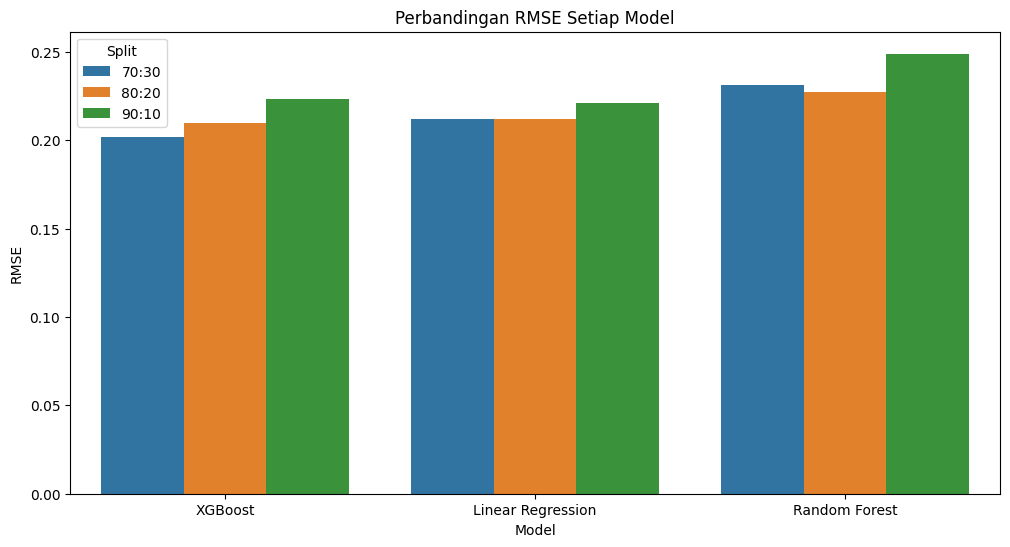

In [29]:
plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Split')
plt.title('Perbandingan RMSE Setiap Model')
plt.show()

**Cek Overfitting**

In [30]:
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

# Prediksi
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# R2
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

print("=== Linear Regression ===")
print("Train R2:", r2_train_lr)
print("Test  R2:", r2_test_lr)
print("Selisih :", r2_train_lr - r2_test_lr)

=== Linear Regression ===
Train R2: 0.9488597345863352
Test  R2: 0.9439010203231145
Selisih : 0.004958714263220698


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Prediksi
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# R2
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("\n=== Random Forest ===")
print("Train R2:", r2_train_rf)
print("Test  R2:", r2_test_rf)
print("Selisih :", r2_train_rf - r2_test_rf)


=== Random Forest ===
Train R2: 0.9917359901530711
Test  R2: 0.926622599636992
Selisih : 0.06511339051607912


In [32]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

# Prediksi
y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

# R2
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

print("\n=== XGBoost ===")
print("Train R2:", r2_train_xgb)
print("Test  R2:", r2_test_xgb)
print("Selisih :", r2_train_xgb - r2_test_xgb)


=== XGBoost ===
Train R2: 0.9922994864025767
Test  R2: 0.9352509118848774
Selisih : 0.05704857451769929


**Smpan Model**

In [33]:
import pickle
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
best_model.fit(X_train_90, y_train_90)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [34]:
with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Model berhasil disimpan")

Model berhasil disimpan


# INFERENCE

In [35]:
import joblib
import pandas as pd

model = joblib.load('best_model.pkl')

FEATURES = [
    'StudyTimeWeekly', 'Absences', 'Tutoring',
    'ParentalSupport', 'Extracurricular',
    'Music', 'GradeClass'

]

def predict_gpa(input_data):
    # ubah input jadi DataFrame
    input_df = pd.DataFrame([input_data])

    # pastikan urutan kolom sama dengan training
    input_df = input_df[FEATURES]

    # prediksi
    prediction = model.predict(input_df)[0]

    return round(float(prediction), 2)

In [36]:

sample_user = {
    'StudyTimeWeekly': 10.5,
    'Absences': 5,
    'Tutoring': 1,
    'ParentalSupport': 3,
    'Extracurricular': 1,
    'Music': 1,
    'GradeClass' : 0
}

result = predict_gpa(sample_user)
print(f"Prediksi GPA: {result}")

Prediksi GPA: 3.53


**TEST DATA KUESIONER (REAL TEST)**

In [37]:
df_kuesioner = pd.read_csv('/content/_Kuesioner Penelitian_ Data Akademik Mahasiswa untuk Prediksi Performa Akademik.  (Jawaban) - Form Responses 1 (3).csv')
df_kuesioner.head()

,Timestamp,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,14/04/2026 22:37:55,4050,19,Female,0,3,14,0,0,2,0,0,0,0,3.79,A
1,14/04/2026 22:38:33,4063,20,male,0,3,7,3,1,2,0,1,0,0,3.30,B
2,14/04/2026 22:40:31,4017,17,Female,3,3,1,39,1,3,0,0,0,0,3.00,A
3,14/04/2026 22:42:13,4045,19,male,0,1,15 jam,1,1,2,1,1,0,1,3.50,A
4,14/04/2026 22:42:25,4018,19,Female,3,3,70,0,1,1,1,1,1,1,4.0,A


In [38]:
df_kuesioner.columns = df_kuesioner.columns.str.strip()

In [39]:
df_kuesioner = df.drop(columns=['Timestamp', 'StudentID', 'Age', 'Volunteering', 'Gender', 'Ethnicity', 'ParentalEducation', 'Sports'], errors='ignore')

In [40]:
print(df_kuesioner.columns)

Index(['StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Music', 'GPA', 'GradeClass'],
      dtype='object')


In [41]:
df_kuesioner.dtypes

,0
StudyTimeWeekly,float64
Absences,int64
Tutoring,int64
ParentalSupport,int64
Extracurricular,int64
Music,int64
GPA,float64
GradeClass,float64


In [42]:
df_kuesioner['StudyTimeWeekly'] = (
    df_kuesioner['StudyTimeWeekly']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(float)
)

In [43]:
df_kuesioner['GPA'] = (
    df_kuesioner['GPA']
    .astype(str)
    .str.replace(',', '.')   # ubah koma ke titik
    .str.strip()             # hapus spasi
    .astype(float)
)

In [44]:
df['GradeClass'] = (
    df['GradeClass']
    .astype(str)
    .str.strip()
    .str.upper()
    .map({'A':0,'B':1,'C':2,'D':3,'E':4,'F':5})
)

In [45]:
df_kuesioner = df_kuesioner[
    (df_kuesioner['StudyTimeWeekly'] <= 25) &
    (df_kuesioner['GPA'] <= 4.0) &
    (df_kuesioner['Absences'] <= 30)
]

In [46]:
df_kuesioner.head()

,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Music,GPA,GradeClass
0,19.0,7,1,2,0,1,2.929196,2.0
1,15.0,0,0,1,0,0,3.042915,1.0
2,4.0,26,0,2,0,0,0.112602,4.0
3,10.0,14,0,3,1,0,2.054218,3.0
4,4.0,17,1,3,0,0,1.288061,4.0


In [47]:
X_test = df_kuesioner.drop('GPA', axis=1)
y_test = df_kuesioner['GPA']

In [48]:
y_pred_lr = lr.predict(X_test)

In [49]:
y_pred_rf = rf.predict(X_test)

In [50]:
y_pred_xgb = xgb.predict(X_test)

In [51]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2

In [52]:
lr_mae, lr_rmse, lr_r2 = evaluate(y_test, y_pred_lr)
rf_mae, rf_rmse, rf_r2 = evaluate(y_test, y_pred_rf)
xgb_mae, xgb_rmse, xgb_r2 = evaluate(y_test, y_pred_xgb)

In [53]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    'R2 Score': [lr_r2, rf_r2, xgb_r2]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.168253  0.208416  0.948114
1      Random Forest  0.106106  0.148619  0.973616
2            XGBoost  0.121533  0.163342  0.968129
